In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("quiz_responses.csv")

print(df.shape)
print(df.head())

(59, 16)
   id           user_id group_name                  start_time  \
0   7  1776377177_90285          B  2026-04-16 18:06:17.799408   
1   8  1776377402_55428          A   2026-04-16 22:10:02.10855   
2   9  1776377437_44387          B  2026-04-16 22:10:37.145804   
3  10  1776377793_37256          B  2026-04-16 22:16:33.846366   
4  11  1776377773_26377          A  2026-04-16 22:16:13.266878   

                  submit_time  duration_sec  score  completed  satisfaction  \
0  2026-04-16 18:06:55.805183     38.005775      5          1             4   
1  2026-04-16 22:10:42.252965     40.144415      5          1             5   
2  2026-04-16 22:11:38.598595     61.452791      3          1             4   
3   2026-04-16 22:17:59.43975     85.593384      5          1             5   
4  2026-04-16 22:19:20.594086    187.327208      4          1             4   

   ease_of_use       q1      q2     q3   q4  q5                     created_at  
0            5  Dolphin    Asia  Water

In [ ]:
correct = {
    "q1": "Dolphin",
    "q2": "Asia",
    "q3": "Water",
    "q4": "1/3",
    "q5": "4"
}

for q, ans in correct.items():
    df[q] = df[q].astype(str).str.strip()
    df[f"{q}_correct"] = (df[q] == str(ans)).astype(int)

A = df[df["group_name"] == "A"].copy()
B = df[df["group_name"] == "B"].copy()

# Duration clean sample (same 3×IQR rule as AB test analysis.ipynb)
q1_dur = df["duration_sec"].quantile(0.25)
q3_dur = df["duration_sec"].quantile(0.75)
iqr_dur = q3_dur - q1_dur
dur_low = max(0.0, q1_dur - 3 * iqr_dur)
dur_high = q3_dur + 3 * iqr_dur
df_clean = df[(df["duration_sec"] >= dur_low) & (df["duration_sec"] <= dur_high)].copy()
A_c = df_clean[df_clean["group_name"] == "A"].copy()
B_c = df_clean[df_clean["group_name"] == "B"].copy()
print(
    f"Duration 3×IQR fences [{dur_low:.2f}, {dur_high:.2f}]: df_clean n={len(df_clean)} (raw n={len(df)})"
)

print("Group A size:", len(A))
print("Group B size:", len(B))

Duration 3×IQR fences [0.00, 313.96]: df_clean n=58 (raw n=59)
Group A size: 31
Group B size: 28


For each outcome, the null hypothesis is that there is no difference between Version A and Version B.
The alternative hypothesis is that the two versions differ in user performance or user experience.

In [23]:
#effect size for main outcomes
def cohens_d(x, y):
    x = np.array(x.dropna())
    y = np.array(y.dropna())
    nx, ny = len(x), len(y)
    sx, sy = np.var(x, ddof=1), np.var(y, ddof=1)
    pooled_sd = np.sqrt(((nx - 1) * sx + (ny - 1) * sy) / (nx + ny - 2))
    return (np.mean(x) - np.mean(y)) / pooled_sd

for metric in ["score", "satisfaction", "ease_of_use"]:
    d = cohens_d(A[metric], B[metric])
    diff = A[metric].mean() - B[metric].mean()
    print(f"{metric}: mean diff (A-B) = {diff:.3f}, Cohen's d = {d:.3f}")

d = cohens_d(A_c["duration_sec"], B_c["duration_sec"])
diff = A_c["duration_sec"].mean() - B_c["duration_sec"].mean()
print(f"duration_sec (duration-cleaned): mean diff (A-B) = {diff:.3f}, Cohen's d = {d:.3f}")

score: mean diff (A-B) = 0.108, Cohen's d = 0.106
satisfaction: mean diff (A-B) = 0.622, Cohen's d = 0.695
ease_of_use: mean diff (A-B) = 0.469, Cohen's d = 0.508
duration_sec (duration-cleaned): mean diff (A-B) = -14.148, Cohen's d = -0.298


In [24]:
#confidence intervals for mean differences
def mean_diff_ci(x, y, alpha=0.05):
    x = np.array(x.dropna())
    y = np.array(y.dropna())
    diff = x.mean() - y.mean()
    se = np.sqrt(x.var(ddof=1)/len(x) + y.var(ddof=1)/len(y))
    z = stats.norm.ppf(1 - alpha/2)
    ci_low = diff - z * se
    ci_high = diff + z * se
    return diff, ci_low, ci_high

for metric in ["score", "satisfaction", "ease_of_use"]:
    diff, low, high = mean_diff_ci(A[metric], B[metric])
    print(f"{metric}: diff = {diff:.3f}, 95% CI = [{low:.3f}, {high:.3f}]")

diff, low, high = mean_diff_ci(A_c["duration_sec"], B_c["duration_sec"])
print(f"duration_sec (duration-cleaned): diff = {diff:.3f}, 95% CI = [{low:.3f}, {high:.3f}]")

score: diff = 0.108, 95% CI = [-0.416, 0.633]
satisfaction: diff = 0.622, 95% CI = [0.161, 1.083]
ease_of_use: diff = 0.469, 95% CI = [-0.004, 0.941]
duration_sec (duration-cleaned): diff = -14.148, 95% CI = [-38.255, 9.959]


In [25]:
#per-question significance test
results_q = []

for q in ["q1", "q2", "q3", "q4", "q5"]:
    count = np.array([A[f"{q}_correct"].sum(), B[f"{q}_correct"].sum()])
    nobs = np.array([len(A), len(B)])
    stat, pval = proportions_ztest(count, nobs)
    
    acc_a = A[f"{q}_correct"].mean()
    acc_b = B[f"{q}_correct"].mean()
    
    results_q.append({
        "question": q,
        "acc_A": acc_a,
        "acc_B": acc_b,
        "diff_A_minus_B": acc_a - acc_b,
        "p_value": pval
    })

q_results = pd.DataFrame(results_q)
print(q_results)

  question     acc_A     acc_B  diff_A_minus_B   p_value
0       q1  0.838710  0.964286       -0.125576  0.111026
1       q2  0.935484  0.714286        0.221198  0.023737
2       q3  0.903226  0.857143        0.046083  0.584649
3       q4  0.838710  0.821429        0.017281  0.859769
4       q5  0.806452  0.857143       -0.050691  0.604299


In [26]:
# regression to satisdaction
df["group_B"] = (df["group_name"] == "B").astype(int)

model1 = smf.ols("satisfaction ~ group_B + score + duration_sec", data=df).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:           satisfaction   R-squared:                       0.272
Model:                            OLS   Adj. R-squared:                  0.233
Method:                 Least Squares   F-statistic:                     6.861
Date:                Sat, 18 Apr 2026   Prob (F-statistic):           0.000522
Time:                        20:29:06   Log-Likelihood:                -70.265
No. Observations:                  59   AIC:                             148.5
Df Residuals:                      55   BIC:                             156.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        2.5096      0.505      4.968   

In [27]:
# regression to ease_of_use
model2 = smf.ols("ease_of_use ~ group_B + score + duration_sec", data=df).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:            ease_of_use   R-squared:                       0.196
Model:                            OLS   Adj. R-squared:                  0.152
Method:                 Least Squares   F-statistic:                     4.472
Date:                Sat, 18 Apr 2026   Prob (F-statistic):            0.00701
Time:                        20:29:06   Log-Likelihood:                -73.399
No. Observations:                  59   AIC:                             154.8
Df Residuals:                      55   BIC:                             163.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        2.7796      0.533      5.218   

In [28]:
#cleaner summary table
summary_rows = []

for metric in ["score", "satisfaction", "ease_of_use"]:
    t_stat, p_val = stats.ttest_ind(A[metric], B[metric], equal_var=False)
    diff, low, high = mean_diff_ci(A[metric], B[metric])
    d = cohens_d(A[metric], B[metric])
    summary_rows.append({
        "metric": metric,
        "mean_A": round(A[metric].mean(), 3),
        "mean_B": round(B[metric].mean(), 3),
        "diff_A_minus_B": round(diff, 3),
        "95%_CI": f"[{low:.3f}, {high:.3f}]",
        "p_value": round(p_val, 4),
        "cohens_d": round(d, 3),
    })

metric = "duration_sec"
_, p_val = stats.mannwhitneyu(
    A_c[metric], B_c[metric], alternative="two-sided"
)
diff, low, high = mean_diff_ci(A_c[metric], B_c[metric])
d = cohens_d(A_c[metric], B_c[metric])
summary_rows.append({
    "metric": metric,
    "mean_A": round(A_c[metric].mean(), 3),
    "mean_B": round(B_c[metric].mean(), 3),
    "diff_A_minus_B": round(diff, 3),
    "95%_CI": f"[{low:.3f}, {high:.3f}]",
    "p_value": round(p_val, 4),
    "cohens_d": round(d, 3),
})

summary_table = pd.DataFrame(summary_rows)
summary_table

,metric,mean_A,mean_B,diff_A_minus_B,95%_CI,p_value,cohens_d
0,score,4.323,4.214,0.108,"[-0.416, 0.633]",0.6872,0.106
1,satisfaction,4.194,3.571,0.622,"[0.161, 1.083]",0.0107,0.695
2,ease_of_use,4.290,3.821,0.469,"[-0.004, 0.941]",0.0568,0.508
3,duration_sec,78.520,92.668,-14.148,"[-38.255, 9.959]",0.0526,-0.298


In [29]:
df_clean["efficiency"] = df_clean["score"] / df_clean["duration_sec"]
A_eff = df_clean[df_clean["group_name"] == "A"].copy()
B_eff = df_clean[df_clean["group_name"] == "B"].copy()

from scipy import stats
stats.ttest_ind(A_eff["efficiency"], B_eff["efficiency"], equal_var=False)

TtestResult(statistic=2.4062050504163213, pvalue=0.02073544820254771, df=40.79346047499588)

In [30]:
# Efficiency uses duration-cleaned rows only (score/duration on df_clean)
df_clean["efficiency"] = df_clean["score"] / df_clean["duration_sec"]
A_eff = df_clean[df_clean["group_name"] == "A"].copy()
B_eff = df_clean[df_clean["group_name"] == "B"].copy()

t_eff, p_eff = stats.ttest_ind(A_eff["efficiency"], B_eff["efficiency"], equal_var=False)
diff_eff, low_eff, high_eff = mean_diff_ci(A_eff["efficiency"], B_eff["efficiency"])
d_eff = cohens_d(A_eff["efficiency"], B_eff["efficiency"])

print("Efficiency Analysis (duration-cleaned sample)")
print("-" * 50)
print(f"Mean efficiency A = {A_eff['efficiency'].mean():.4f}")
print(f"Mean efficiency B = {B_eff['efficiency'].mean():.4f}")
print(f"Mean diff (A-B) = {diff_eff:.4f}")
print(f"95% CI = [{low_eff:.4f}, {high_eff:.4f}]")
print(f"p-value = {p_eff:.4f}")
print(f"Cohen's d = {d_eff:.3f}")

Efficiency Analysis (duration-cleaned sample)
--------------------------------------------------
Mean efficiency A = 0.0867
Mean efficiency B = 0.0548
Mean diff (A-B) = 0.0319
95% CI = [0.0059, 0.0578]
p-value = 0.0207
Cohen's d = 0.618


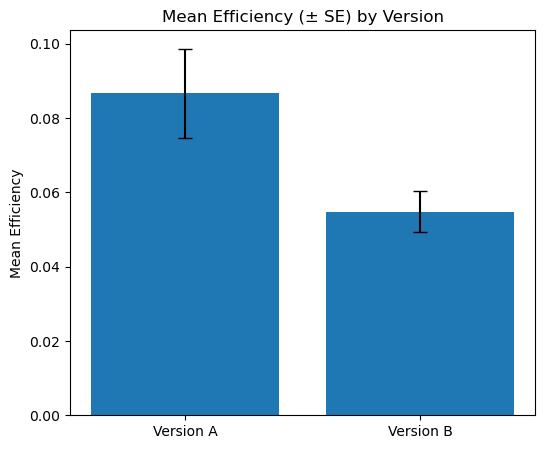

In [31]:
means = [A_eff["efficiency"].mean(), B_eff["efficiency"].mean()]
se = [A_eff["efficiency"].sem(), B_eff["efficiency"].sem()]

plt.figure(figsize=(6,5))

plt.bar(["Version A", "Version B"], means, yerr=se, capsize=5)

plt.ylabel("Mean Efficiency")
plt.title("Mean Efficiency (± SE) by Version")

plt.show()

In [32]:
#High Performance Rate
df["high_score"] = (df["score"] >= 4).astype(int)

A = df[df["group_name"] == "A"]
B = df[df["group_name"] == "B"]

from statsmodels.stats.proportion import proportions_ztest

count = [A["high_score"].sum(), B["high_score"].sum()]
nobs = [len(A), len(B)]

stat, pval = proportions_ztest(count, nobs)

print("High score rate A:", A["high_score"].mean())
print("High score rate B:", B["high_score"].mean())
print("p-value:", pval)

High score rate A: 0.8387096774193549
High score rate B: 0.75
p-value: 0.3979363562618172


In [33]:
#Fast Completion Rate 
threshold = df["duration_sec"].median()

df["fast"] = (df["duration_sec"] <= threshold).astype(int)

A = df[df["group_name"] == "A"]
B = df[df["group_name"] == "B"]

count = [A["fast"].sum(), B["fast"].sum()]
nobs = [len(A), len(B)]

stat, pval = proportions_ztest(count, nobs)

print("Fast rate A:", A["fast"].mean())
print("Fast rate B:", B["fast"].mean())
print("p-value:", pval)

Fast rate A: 0.7419354838709677
Fast rate B: 0.42857142857142855
p-value: 0.014413770394769284


A significantly higher proportion of users in Version A complete the quiz quickly compared to Version B (p = 0.014), indicating that Version A facilitates faster task completion.

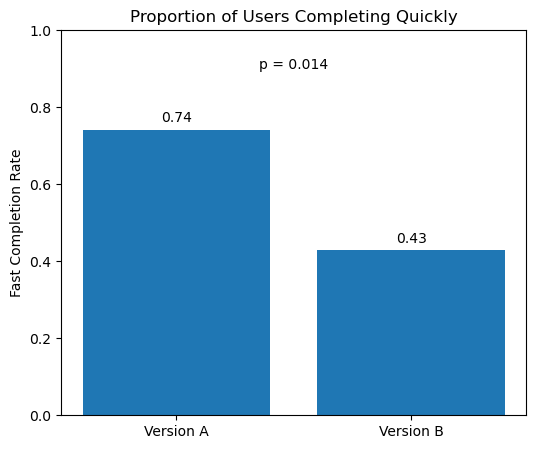

In [34]:
rates = [A["fast"].mean(), B["fast"].mean()]
labels = ["Version A", "Version B"]

plt.figure(figsize=(6,5))

plt.bar(labels, rates)

plt.ylim(0, 1)
plt.ylabel("Fast Completion Rate")
plt.title("Proportion of Users Completing Quickly")

for i, v in enumerate(rates):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')

plt.text(0.5, 0.9, f"p = {pval:.3f}", ha='center')

plt.show()

In [35]:
#High Satisfaction Rate
df["high_sat"] = (df["satisfaction"] >= 4).astype(int)

A = df[df["group_name"] == "A"]
B = df[df["group_name"] == "B"]

count = [A["high_sat"].sum(), B["high_sat"].sum()]
nobs = [len(A), len(B)]

stat, pval = proportions_ztest(count, nobs)

print("High satisfaction A:", A["high_sat"].mean())
print("High satisfaction B:", B["high_sat"].mean())
print("p-value:", pval)

High satisfaction A: 0.7419354838709677
High satisfaction B: 0.39285714285714285
p-value: 0.006737183844866298


The proportion of highly satisfied users is significantly higher in Version A (p = 0.0067), indicating a clear advantage in user experience.

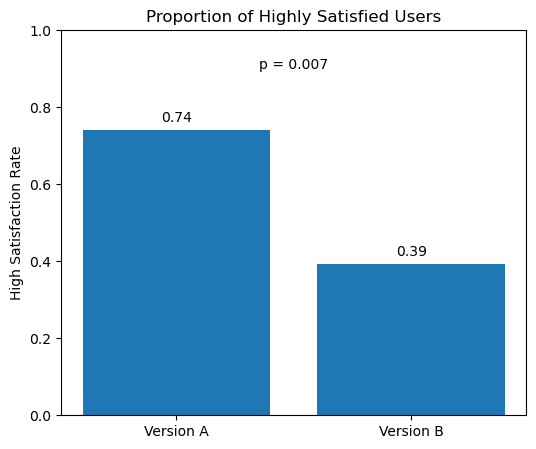

In [36]:
rates = [A["high_sat"].mean(), B["high_sat"].mean()]
labels = ["Version A", "Version B"]

plt.figure(figsize=(6,5))

plt.bar(labels, rates)

plt.ylim(0, 1)
plt.ylabel("High Satisfaction Rate")
plt.title("Proportion of Highly Satisfied Users")

for i, v in enumerate(rates):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')

# p-value
plt.text(0.5, 0.9, f"p = {pval:.3f}", ha='center')

plt.show()

In [37]:
#Combined Success Metric
score_th = 4
time_th = df["duration_sec"].median()

df["success"] = ((df["score"] >= score_th) & (df["duration_sec"] <= time_th)).astype(int)

A = df[df["group_name"] == "A"]
B = df[df["group_name"] == "B"]

count = [A["success"].sum(), B["success"].sum()]
nobs = [len(A), len(B)]

stat, pval = proportions_ztest(count, nobs)

print("Success rate A:", A["success"].mean())
print("Success rate B:", B["success"].mean())
print("p-value:", pval)

Success rate A: 0.5806451612903226
Success rate B: 0.32142857142857145
p-value: 0.045968322409366796


The success rate, defined as achieving both high performance and fast completion, is significantly higher in Version A (p = 0.046), suggesting that Version A is more effective in supporting successful task completion.

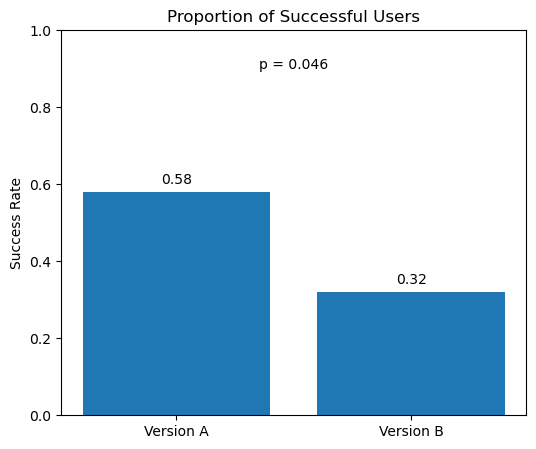

In [38]:
rates = [A["success"].mean(), B["success"].mean()]
labels = ["Version A", "Version B"]

plt.figure(figsize=(6,5))

plt.bar(labels, rates)

plt.ylim(0, 1)
plt.ylabel("Success Rate")
plt.title("Proportion of Successful Users")

for i, v in enumerate(rates):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')

plt.text(0.5, 0.9, f"p = {pval:.3f}", ha='center')

plt.show()

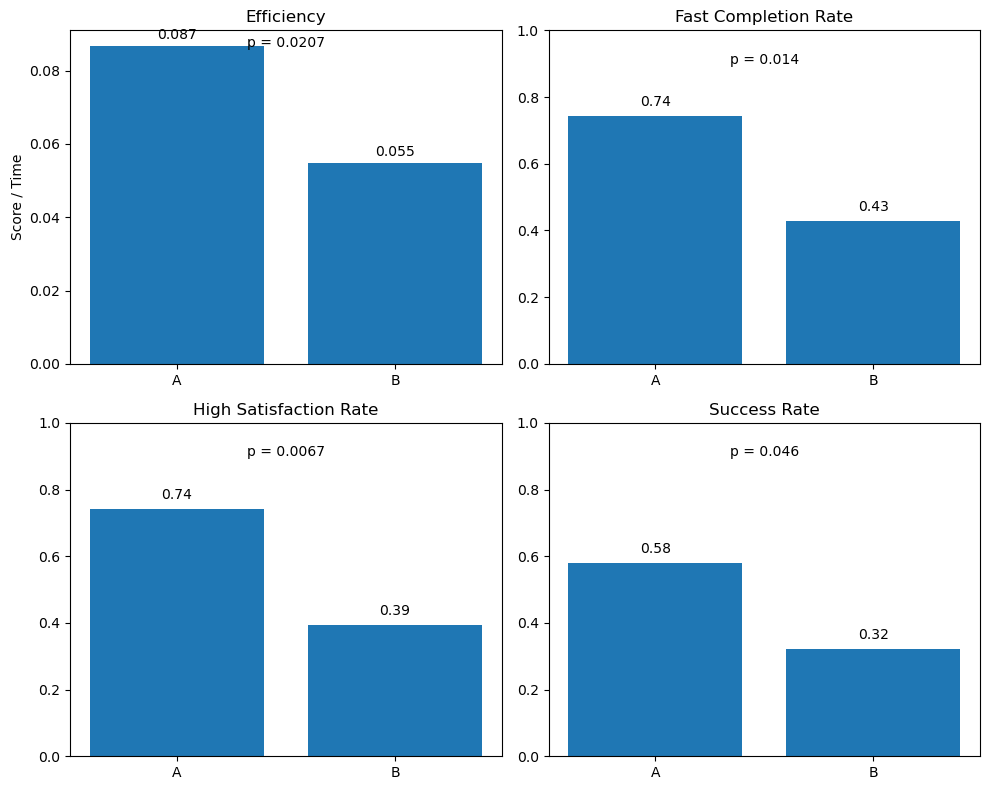

In [39]:
import matplotlib.pyplot as plt
import numpy as np

#calculate (efficiency uses duration-cleaned sample; other rates use full raw df)
eff_A = A_eff["efficiency"].mean()
eff_B = B_eff["efficiency"].mean()

fast_A = A["fast"].mean()
fast_B = B["fast"].mean()

sat_A = A["high_sat"].mean()
sat_B = B["high_sat"].mean()

succ_A = A["success"].mean()
succ_B = B["success"].mean()

# p-values (p_eff from efficiency analysis cell above)
p_fast = 0.014
p_sat = 0.0067
p_succ = 0.046

# plot 4 figures
fig, axes = plt.subplots(2, 2, figsize=(10,8))

# ---------- 1. Efficiency ----------
axes[0,0].bar(["A", "B"], [eff_A, eff_B])
axes[0,0].set_title("Efficiency")
axes[0,0].set_ylabel("Score / Time")

for i, v in enumerate([eff_A, eff_B]):
    axes[0,0].text(i, v + 0.002, f"{v:.3f}", ha='center')

axes[0,0].text(0.5, 0.95, f"p = {p_eff:.4f}",
               ha='center', transform=axes[0,0].transAxes)


# ---------- 2. Fast Completion ----------
axes[0,1].bar(["A", "B"], [fast_A, fast_B])
axes[0,1].set_title("Fast Completion Rate")
axes[0,1].set_ylim(0,1)

for i, v in enumerate([fast_A, fast_B]):
    axes[0,1].text(i, v + 0.03, f"{v:.2f}", ha='center')

axes[0,1].text(0.5, 0.9, f"p = {p_fast}", ha='center')


# ---------- 3. High Satisfaction ----------
axes[1,0].bar(["A", "B"], [sat_A, sat_B])
axes[1,0].set_title("High Satisfaction Rate")
axes[1,0].set_ylim(0,1)

for i, v in enumerate([sat_A, sat_B]):
    axes[1,0].text(i, v + 0.03, f"{v:.2f}", ha='center')

axes[1,0].text(0.5, 0.9, f"p = {p_sat}", ha='center')


# ---------- 4. Success Rate ----------
axes[1,1].bar(["A", "B"], [succ_A, succ_B])
axes[1,1].set_title("Success Rate")
axes[1,1].set_ylim(0,1)

for i, v in enumerate([succ_A, succ_B]):
    axes[1,1].text(i, v + 0.03, f"{v:.2f}", ha='center')

axes[1,1].text(0.5, 0.9, f"p = {p_succ}", ha='center')


plt.tight_layout()
plt.show()

In [40]:
import numpy as np
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest

threshold_results = []

for q in [0.4, 0.5, 0.6]:
    time_th = df["duration_sec"].quantile(q)
    df[f"fast_q{int(q*100)}"] = (df["duration_sec"] <= time_th).astype(int)
    df[f"success_q{int(q*100)}"] = ((df["score"] >= 4) & (df["duration_sec"] <= time_th)).astype(int)

    A = df[df["group_name"] == "A"]
    B = df[df["group_name"] == "B"]

    # fast
    count_fast = [A[f"fast_q{int(q*100)}"].sum(), B[f"fast_q{int(q*100)}"].sum()]
    nobs = [len(A), len(B)]
    _, p_fast = proportions_ztest(count_fast, nobs)

    # success
    count_success = [A[f"success_q{int(q*100)}"].sum(), B[f"success_q{int(q*100)}"].sum()]
    _, p_success = proportions_ztest(count_success, nobs)

    threshold_results.append({
        "quantile_threshold": q,
        "time_threshold": round(time_th, 2),
        "fast_rate_A": round(A[f"fast_q{int(q*100)}"].mean(), 3),
        "fast_rate_B": round(B[f"fast_q{int(q*100)}"].mean(), 3),
        "fast_p_value": round(p_fast, 4),
        "success_rate_A": round(A[f"success_q{int(q*100)}"].mean(), 3),
        "success_rate_B": round(B[f"success_q{int(q*100)}"].mean(), 3),
        "success_p_value": round(p_success, 4)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,quantile_threshold,time_threshold,fast_rate_A,fast_rate_B,fast_p_value,success_rate_A,success_rate_B,success_p_value
0,0.4,61.66,0.484,0.321,0.2047,0.323,0.214,0.3501
1,0.5,86.62,0.742,0.429,0.0144,0.581,0.321,0.0460
2,0.6,89.25,0.742,0.429,0.0144,0.581,0.321,0.0460
